# Train a model to predict if a person is prone to has a heart disease

## import the data

In [1]:
import pandas as pd
data = pd.read_csv("data/heart.csv")

In [2]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## data imputation

In [5]:
import numpy as np
data[["RestingBP", "Cholesterol"]] = data[["RestingBP", "Cholesterol"]].replace(0, np.nan)
data.isna().sum()   

Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

In [6]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
data[["RestingBP", "Cholesterol"]] = imputer.fit_transform(data[["RestingBP", "Cholesterol"]])

## EDA

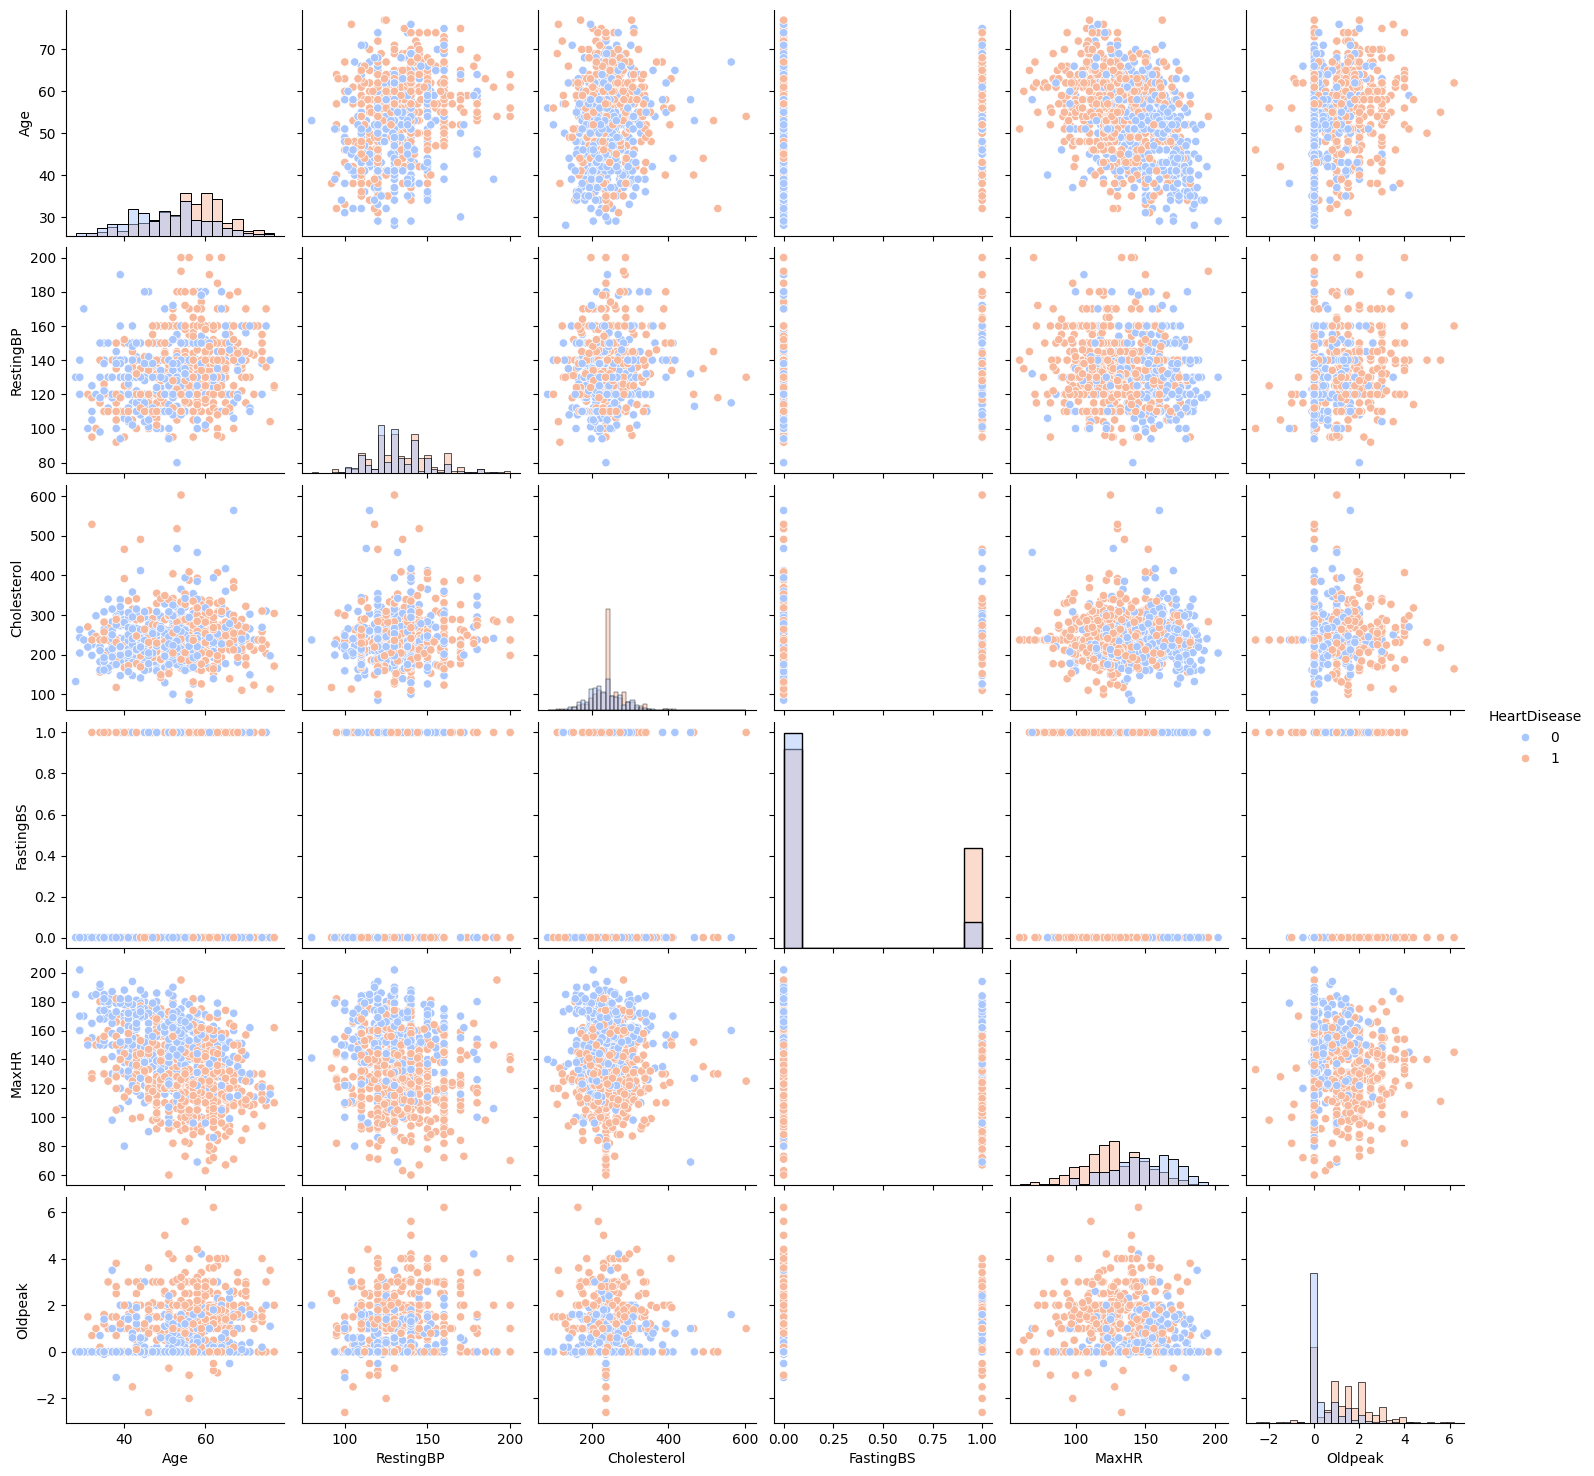

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.pairplot(data , hue="HeartDisease" ,diag_kind="hist" ,palette="coolwarm")
plt.show()

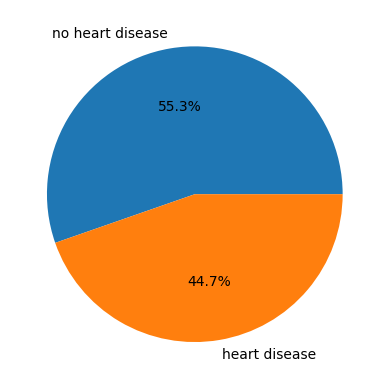

In [8]:
plt.pie(data["HeartDisease"].value_counts(), labels=["no heart disease", "heart disease"], autopct='%1.1f%%')
plt.show()

## data preprocessing

In [9]:
x = data.drop("HeartDisease", axis=1)
y = data["HeartDisease"]

In [10]:
x_encoded = pd.get_dummies(x, columns=x.select_dtypes(include="object").columns.tolist(), drop_first=True)

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, stratify=y, random_state=42)

In [12]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_xtrain = scaler.fit_transform(X_train)
scaled_xtest = scaler.transform(X_test)

## create the model

In [13]:
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.01, 0.1, 1, 10, 100]
    },{
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 0.01, 0.1, 1]
    },{
        'kernel': ['poly'],
        'C': [0.1, 1, 10],
        'degree': [2, 3],
        'gamma': ['scale', 0.1]
    }
]

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

svc = SVC(probability=True)

grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

## train the model

In [15]:
grid_search.fit(scaled_xtrain, y_train)

Fitting 5 folds for each of 33 candidates, totalling 165 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(probability=True)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.01, 0.1, ...], 'kernel': ['linear']}, {'C': [0.1, 1, ...], 'gamma': ['scale', 0.01, ...], 'kernel': ['rbf']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

## evaluate the model

In [16]:
best_svc = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)

print("Best CV score:")
print(grid_search.best_score_)

Best parameters:
{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV score:
0.9184096822579206


In [17]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = best_svc.predict(scaled_xtest)
y_proba = best_svc.predict_proba(scaled_xtest)[:, 1]

print(classification_report(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.89      0.82      0.85        82
           1       0.86      0.92      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88      0.88      0.87       184

Test ROC AUC: 0.9323290291726447


In [18]:
from sklearn.metrics import accuracy_score

model = SVC()
model.fit(scaled_xtrain , y_train)
prediction = model.predict(scaled_xtest)
print("test Accuracy : ",'{0:.2%}'.format(accuracy_score(y_test,prediction)))
prediction = model.predict(scaled_xtrain)
print("train Accuracy : ",'{0:.2%}'.format(accuracy_score(y_train,prediction)))

test Accuracy :  86.41%
train Accuracy :  87.87%
